In [2]:
# ============================================================
# IMPORTS
# ============================================================

import time
import pandas as pd

from bs4 import BeautifulSoup

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

In [3]:
# ============================================================
# CONFIGURATION
# ============================================================

TARGET_REVIEWS = 300

REVIEW_URL = (
    "https://www.flipkart.com/apple-iphone-15-black-128-gb/"
    "product-reviews/itm6ac6485515ae4"
)

SCROLL_WAIT = 4

# ============================================================
# START CHROME
# ============================================================

options = Options()

# Uncomment if needed
# options.add_argument("--headless=new")

options.add_argument("--start-maximized")

driver = webdriver.Chrome(options=options)

driver.get(REVIEW_URL)

time.sleep(5)

# ============================================================
# STORAGE
# ============================================================

reviews = []
seen_reviews = set()

previous_count = 0
stagnant_scrolls = 0

# ============================================================
# SCRAPE LOOP
# ============================================================

for scroll_no in range(300):

    print("\n" + "="*60)
    print(f"SCROLL #{scroll_no}")
    print(f"REVIEWS COLLECTED: {len(reviews)}")
    print("="*60)

    review_elements = driver.find_elements(
        By.XPATH,
        "//*[contains(text(),'Verified Purchase')]"
    )

    print("Visible review cards:", len(review_elements))

    # --------------------------------------------------------
    # EXTRACT REVIEWS
    # --------------------------------------------------------

    for review in review_elements:

        try:

            card = review.find_element(
                By.XPATH,
                "./ancestor::div[10]"
            )

            html = card.get_attribute("outerHTML")

            soup = BeautifulSoup(
                html,
                "html.parser"
            )

            blocks = []

            for tag in soup.select("div.css-146c3p1"):

                txt = tag.get_text(strip=True)

                if txt:
                    blocks.append(txt)

            # Skip malformed cards
            if len(blocks) < 11:
                continue

            review_rating = blocks[0]
            review_title = blocks[2]
            review_text = blocks[4]
            reviewer_name = blocks[5]
            review_date = blocks[10]

            unique_key = (
                reviewer_name,
                review_text
            )

            if unique_key in seen_reviews:
                continue

            seen_reviews.add(unique_key)

            reviews.append(
                {
                    "reviewer_name": reviewer_name,
                    "review_rating": review_rating,
                    "review_title": review_title,
                    "review_text": review_text,
                    "review_date": review_date
                }
            )

        except Exception:
            pass

    print("Unique Reviews:", len(reviews))

    # --------------------------------------------------------
    # TARGET REACHED
    # --------------------------------------------------------

    if len(reviews) >= TARGET_REVIEWS:

        print(f"\nTarget {TARGET_REVIEWS} reached.")
        break

    # --------------------------------------------------------
    # SCROLL DOWN
    # --------------------------------------------------------

    driver.execute_script(
        "window.scrollTo(0, document.body.scrollHeight);"
    )

    time.sleep(SCROLL_WAIT)

    # --------------------------------------------------------
    # CHECK IF NEW REVIEWS APPEARED
    # --------------------------------------------------------

    current_count = len(
        driver.find_elements(
            By.XPATH,
            "//*[contains(text(),'Verified Purchase')]"
        )
    )

    if current_count <= previous_count:

        stagnant_scrolls += 1

        print(
            f"No new reviews loaded "
            f"({stagnant_scrolls}/8)"
        )

    else:

        stagnant_scrolls = 0

    previous_count = current_count

    if stagnant_scrolls >= 8:

        print("\nNo more reviews loading.")
        break

# ============================================================
# CLOSE DRIVER
# ============================================================

driver.quit()

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(reviews)

# Remove duplicates
df = df.drop_duplicates()

# ============================================================
# REVIEW LENGTH (WORD COUNT)
# ============================================================

df["review_length"] = (
    df["review_text"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

# ============================================================
# DATA QUALITY CHECKS
# ============================================================

# Remove blank reviews
df = df[
    df["review_text"]
    .astype(str)
    .str.strip() != ""
]

# Convert rating to numeric
df["review_rating"] = pd.to_numeric(
    df["review_rating"],
    errors="coerce"
)

# Reset index
df = df.reset_index(drop=True)

# ============================================================
# SUMMARY STATISTICS
# ============================================================

print("\n")
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print(f"Total Reviews: {len(df)}")
print(f"Average Rating: {round(df['review_rating'].mean(), 2)}")
print(f"Average Review Length: {round(df['review_length'].mean(), 2)} words")

# ============================================================
# RESULTS
# ============================================================

print("\n")
print("=" * 60)
print("FINAL DATA SAMPLE")
print("=" * 60)

pd.set_option("display.max_colwidth", None)

display(
    df[
        [
            "reviewer_name",
            "review_rating",
            "review_title",
            "review_text",
            "review_length",
            "review_date"
        ]
    ].head(20)
)

# ============================================================
# EXPORT CSV
# ============================================================

csv_file = "flipkart_reviews.csv"

df.to_csv(
    csv_file,
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# EXPORT EXCEL
# ============================================================

excel_file = "flipkart_reviews.xlsx"

df.to_excel(
    excel_file,
    index=False,
    engine="openpyxl"
)

# ============================================================
# EXPORT REVIEW LENGTH SUMMARY
# ============================================================

review_length_summary = (
    df["review_length"]
    .describe()
)

print("\n")
print("=" * 60)
print("REVIEW LENGTH SUMMARY")
print("=" * 60)

print(review_length_summary)

# ============================================================
# SUCCESS MESSAGE
# ============================================================

print("\nFiles Exported Successfully")
print(f"CSV   : {csv_file}")
print(f"Excel : {excel_file}")

print("\nFinal Columns:")
print(df.columns.tolist())


SCROLL #0
REVIEWS COLLECTED: 0
Visible review cards: 20
Unique Reviews: 20

SCROLL #1
REVIEWS COLLECTED: 20
Visible review cards: 30
Unique Reviews: 30
No new reviews loaded (1/8)

SCROLL #2
REVIEWS COLLECTED: 30
Visible review cards: 30
Unique Reviews: 30

SCROLL #3
REVIEWS COLLECTED: 30
Visible review cards: 40
Unique Reviews: 39
No new reviews loaded (1/8)

SCROLL #4
REVIEWS COLLECTED: 39
Visible review cards: 40
Unique Reviews: 39

SCROLL #5
REVIEWS COLLECTED: 39
Visible review cards: 50
Unique Reviews: 49

SCROLL #6
REVIEWS COLLECTED: 49
Visible review cards: 60
Unique Reviews: 59

SCROLL #7
REVIEWS COLLECTED: 59
Visible review cards: 80
Unique Reviews: 76

SCROLL #8
REVIEWS COLLECTED: 76
Visible review cards: 90
Unique Reviews: 85

SCROLL #9
REVIEWS COLLECTED: 85
Visible review cards: 100
Unique Reviews: 94

SCROLL #10
REVIEWS COLLECTED: 94
Visible review cards: 106
Unique Reviews: 96

SCROLL #11
REVIEWS COLLECTED: 96
Visible review cards: 126
Unique Reviews: 104

SCROLL #12
REV

,reviewer_name,review_rating,review_title,review_text,review_length,review_date
0,ABIR MODAK,5.0,Perfect product!,The camera quality is just awesome ..just like DSLR,9,"· Feb, 2024"
1,subhabrata paul,5.0,Mind-blowing purchase,Fully satisfied using iphone❤️\nBut battery drains fast as compared to any other phone..,14,"· Oct, 2024"
2,Kesab Pradhan,4.0,Value-for-money,Nice photo,2,"· Aug, 2024"
3,Neeraj Chouhan,5.0,Wonderful,Amezing camera and all over best phone👌,7,"· Nov, 2024"
4,Nikhil Kumar,5.0,Awesome,Switch from OnePlus to iPhone I am stunned with camera performance. Everything is perfect on iPhone 15.,17,"· Jan, 2024"
5,Thakur Surya Pratap Singh,5.0,Fabulous!,Awesome 😎,2,"· Jan, 2025"
6,Flipkart Customer,5.0,Must buy!,Using this Iphone 15 from 1month and it has best Camera,11,"· Apr, 2024"
7,Flipkart Customer,5.0,Worth every penny,Awesome photography experience. Battery backup is good . Display is much better than 14 version.,15,"· Jan, 2024"
8,Rishi Jha,5.0,Just wow!,Awesome 🔥🔥☺️,2,"· Apr, 2024"
9,Arunji Govindaraju,5.0,Excellent,"Awesome product very happy to hold this. Better In hand feel,matte finish. \nGood camera, Brighter screen with Dynamic Island, USB-C, great battery life.\n\n60Hz display is a dealbreaker for some.Its not...more",31,"· Feb, 2024"




REVIEW LENGTH SUMMARY
count    118.000000
mean      12.703390
std       11.503481
min        1.000000
25%        3.000000
50%        8.500000
75%       19.000000
max       40.000000
Name: review_length, dtype: float64

Files Exported Successfully
CSV   : flipkart_reviews.csv
Excel : flipkart_reviews.xlsx

Final Columns:
['reviewer_name', 'review_rating', 'review_title', 'review_text', 'review_date', 'review_length']


In [4]:
# ============================================================
# NLP TEXT CLEANING PIPELINE
# ============================================================

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required resources (run once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# ============================================================
# REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates(subset="review_text")

# ============================================================
# REMOVE NULLS
# ============================================================

df = df.dropna(subset=["review_text", "review_rating"])

# ============================================================
# CLEAN REVIEW COLUMN
# ============================================================

df["clean_review"] = df["review_text"].str.lower()

# remove special chars
df["clean_review"] = df["clean_review"].apply(
    lambda x: re.sub(r"[^a-z\s]", " ", x)
)

# remove extra spaces
df["clean_review"] = df["clean_review"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

# remove stopwords
stop_words = set(stopwords.words("english"))

df["clean_review"] = df["clean_review"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

# lemmatization
lemmatizer = WordNetLemmatizer()

df["clean_review"] = df["clean_review"].apply(
    lambda x: " ".join(
        lemmatizer.lemmatize(word)
        for word in x.split()
    )
)

# ============================================================
# SENTIMENT COLUMN (PASTE HERE)
# ============================================================

df["sentiment_text"] = df["review_text"].str.lower()

df["sentiment_text"] = df["sentiment_text"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", " ", str(x))
)

df["sentiment_text"] = df["sentiment_text"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

# ============================================================
# CHECK RESULT
# ============================================================

df[[
    "review_text",
    "clean_review",
    "sentiment_text"
]].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KMGWALANI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\KMGWALANI\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\KMGWALANI\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,review_text,clean_review,sentiment_text
0,The camera quality is just awesome ..just like DSLR,camera quality awesome like dslr,the camera quality is just awesome just like dslr
1,Fully satisfied using iphone❤️\nBut battery drains fast as compared to any other phone..,fully satisfied using iphone battery drain fast compared phone,fully satisfied using iphone but battery drains fast as compared to any other phone
2,Nice photo,nice photo,nice photo
3,Amezing camera and all over best phone👌,amezing camera best phone,amezing camera and all over best phone
4,Switch from OnePlus to iPhone I am stunned with camera performance. Everything is perfect on iPhone 15.,switch oneplus iphone stunned camera performance everything perfect iphone,switch from oneplus to iphone i am stunned with camera performance everything is perfect on iphone


In [5]:
!pip install textblob
from textblob import TextBlob


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# ============================================================
# SENTIMENT CLASSIFICATION FUNCTION
# ============================================================

def get_sentiment(text):

    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0.1:
        return "Positive"

    elif polarity < -0.1:
        return "Negative"

    else:
        return "Neutral"

# ============================================================
# POLARITY SCORE
# ============================================================

df["polarity"] = df["sentiment_text"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

# ============================================================
# SENTIMENT LABEL
# ============================================================

df["sentiment"] = df["sentiment_text"].apply(
    get_sentiment
)
df[
    [
        "review_text",
        "review_rating",
        "polarity",
        "sentiment"
    ]
].head(10)

,review_text,review_rating,polarity,sentiment
0,The camera quality is just awesome ..just like DSLR,5.0,1.000000,Positive
1,Fully satisfied using iphone❤️\nBut battery drains fast as compared to any other phone..,5.0,0.191667,Positive
2,Nice photo,4.0,0.600000,Positive
3,Amezing camera and all over best phone👌,5.0,1.000000,Positive
4,Switch from OnePlus to iPhone I am stunned with camera performance. Everything is perfect on iPhone 15.,5.0,1.000000,Positive
5,Awesome 😎,5.0,1.000000,Positive
6,Using this Iphone 15 from 1month and it has best Camera,5.0,1.000000,Positive
7,Awesome photography experience. Battery backup is good . Display is much better than 14 version.,5.0,0.733333,Positive
8,Awesome 🔥🔥☺️,5.0,1.000000,Positive
9,"Awesome product very happy to hold this. Better In hand feel,matte finish. \nGood camera, Brighter screen with Dynamic Island, USB-C, great battery life.\n\n60Hz display is a dealbreaker for some.Its not...more",5.0,0.535714,Positive


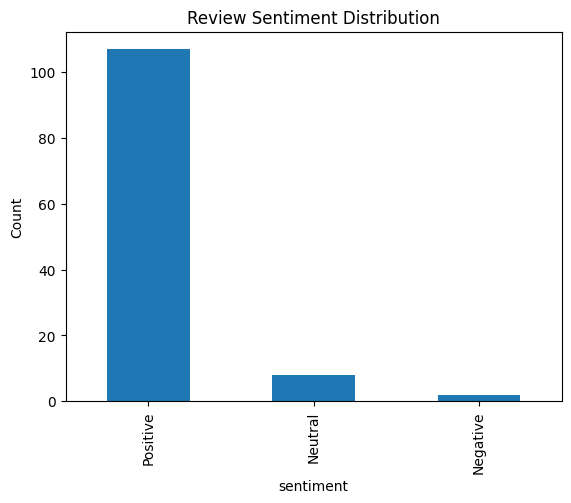

In [7]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Review Sentiment Distribution")
plt.ylabel("Count")

plt.show()

In [8]:
sentiment_summary = (
    df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_summary)

sentiment
Positive    91.45
Neutral      6.84
Negative     1.71
Name: proportion, dtype: float64


In [9]:
# ============================================================
# AVERAGE RATING BY SENTIMENT
# ============================================================

# Ensure rating is numeric

df["review_rating"] = pd.to_numeric(
    df["review_rating"],
    errors="coerce"
)

# Calculate average rating

avg_rating = (
    df.groupby("sentiment")["review_rating"]
      .mean()
      .round(2)
)

print(avg_rating)

sentiment
Negative    1.50
Neutral     4.50
Positive    4.85
Name: review_rating, dtype: float64


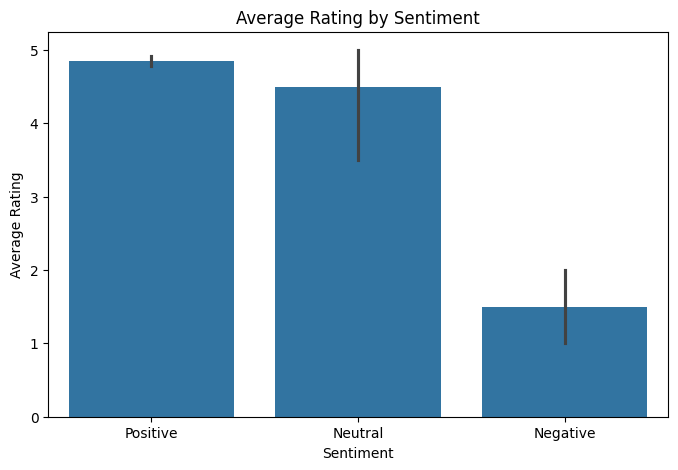

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="sentiment",
    y="review_rating"
)

plt.title("Average Rating by Sentiment")

plt.xlabel("Sentiment")
plt.ylabel("Average Rating")

plt.show()

In [11]:
sentiment_count = (
    df["sentiment"]
    .value_counts()
)

print(sentiment_count)

sentiment
Positive    107
Neutral       8
Negative      2
Name: count, dtype: int64


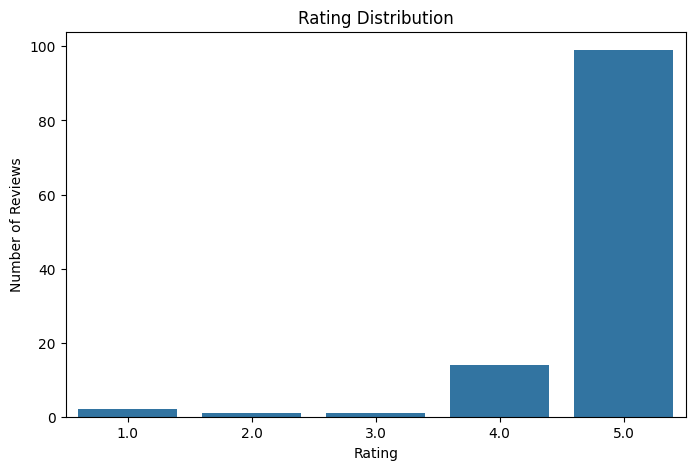

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="review_rating"
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [14]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


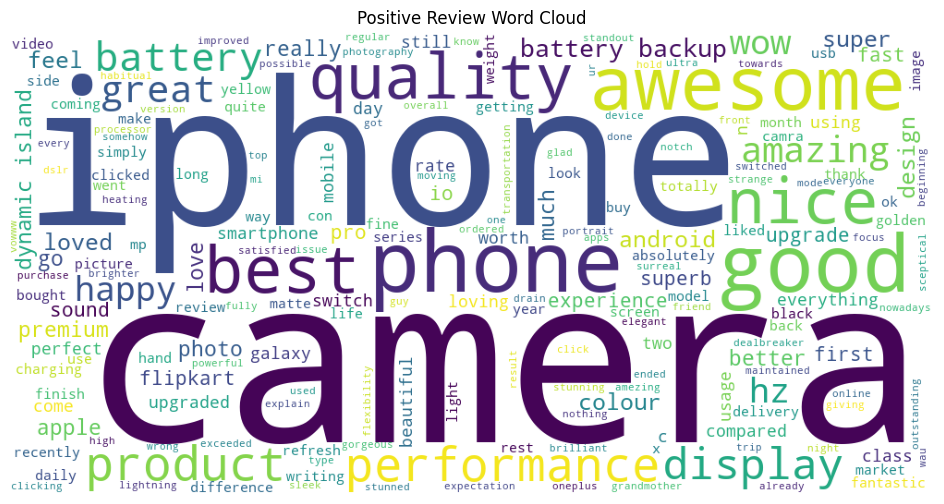

In [15]:
positive_reviews = " ".join(
    df[df["sentiment"]=="Positive"]["clean_review"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Review Word Cloud")
plt.show()

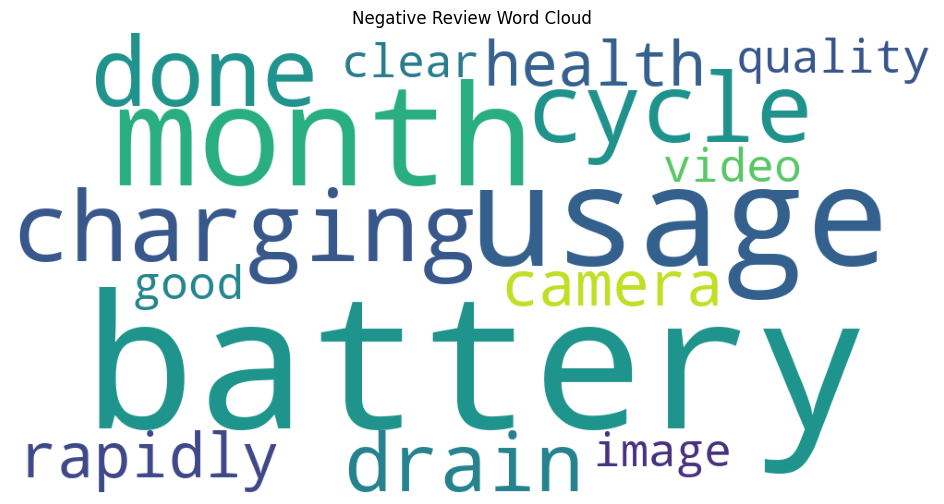

In [16]:
negative_reviews = " ".join(
    df[df["sentiment"]=="Negative"]["clean_review"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Review Word Cloud")
plt.show()

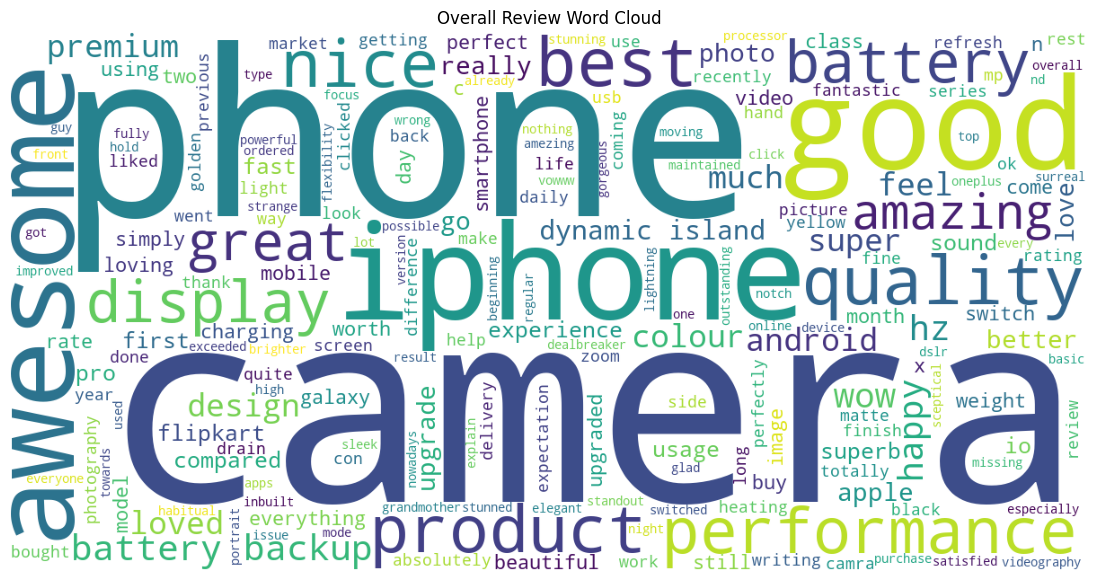

In [17]:
all_reviews = " ".join(
    df["clean_review"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(all_reviews)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Overall Review Word Cloud")
plt.show()

In [18]:
review_length_summary = (
    df.groupby("sentiment")["review_length"]
      .mean()
      .round(2)
)

print(review_length_summary)

sentiment
Negative    15.50
Neutral      9.38
Positive    13.01
Name: review_length, dtype: float64


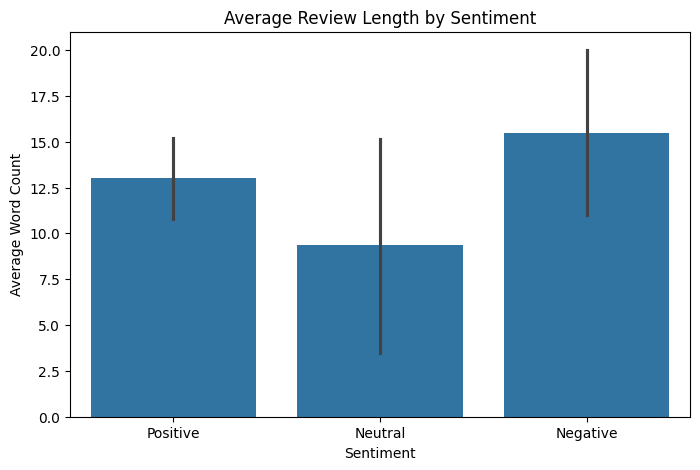

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="sentiment",
    y="review_length"
)

plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Word Count")

plt.show()

In [20]:
correlation = df["review_rating"].corr(df["polarity"])

print("Correlation:", round(correlation,3))

Correlation: 0.289


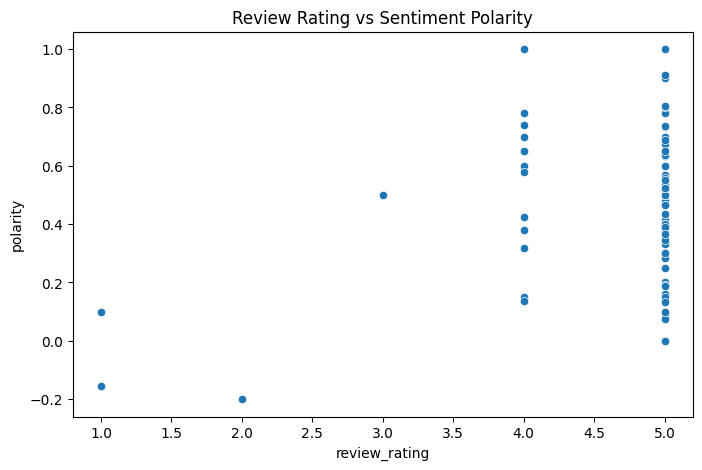

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="review_rating",
    y="polarity"
)

plt.title("Review Rating vs Sentiment Polarity")

plt.show()